In [1]:
import pandas as pd 
mtr_file_path = '../Data/MTR/Selected_Routes.xlsx'
df_mtr = pd.read_excel(mtr_file_path, engine='openpyxl')
df_mtr.head()

,Unnamed: 0,SRC_STATION_ID,DEST_STATION_ID,id,SRC_STATION_NAME,DEST_STATION_NAME,Price,ON_DISTRICT,ON_NAME,ON_SEQUENCE,...,OFF_DISTRICT,OFF_NAME,OFF_SEQUENCE,OFF_LINE,SRC_LAT,SRC_LONG,DEST_LAT,DEST_LONG,DISTANCE,COST_INDEX
0,0,1,2,2,Central,Admiralty,4.9,中西區,中環,13,...,中西區,金鐘,12,ISL,22.282,114.1576,22.2788,114.1646,803.350860,0.054901
1,99,1,26,26,Central,Sheung Wan,4.9,中西區,中環,13,...,中西區,上環,14,ISL,22.282,114.1576,22.2862,114.1518,757.782053,0.051787
2,243,1,81,83,Central,Sai Ying Pun,4.9,中西區,中環,13,...,中西區,西營盤,15,ISL,22.282,114.1576,22.2856,114.1427,1584.469234,0.108284
3,246,1,82,84,Central,HKU,5.9,中西區,中環,13,...,中西區,香港大學,16,ISL,22.282,114.1576,22.2841,114.1356,2275.616627,0.187255
4,249,1,83,85,Central,Kennedy Town,5.9,中西區,中環,13,...,中西區,堅尼地城,17,ISL,22.282,114.1576,22.2812,114.1285,2995.483327,0.246491


In [2]:
factor_file_path = '../Data/Factors/DC_21C.CSV'
df_factor = pd.read_csv(factor_file_path).head(22)
df_factor

,區議會分區（分組),區議會分區,區議會分區（英文名稱),區議會分區（中文名稱),總人口,按性別劃分的人口,按性別劃分的人口.1,性別比率（即男性數目與每千名女性相對的比率）,按年齡組別劃分的人口,按年齡組別劃分的人口.1,...,家庭住戶每月租金（港元）中位數,家庭住戶每月租金與收入比率中位數,家庭住戶的居所樓面面積中位數（平方米）(21),按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.2,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.3,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.2
0,District Council district (class),District Council district,Name of District Council district (in English),Name of District Council district (in Chinese),Total population,Population by sex,Population by sex,Sex ratio (i.e. the number of males per 1 000 ...,Population by age group,Population by age group,...,Median monthly domestic household rent (HK$),Median monthly domestic household rent to inco...,Median floor area of accommodation of domestic...,Population aged 5 and over having internally m...,Population aged 5 and over having internally m...,Population aged 5 and over having internally m...,Population aged 5 and over having internally m...,Population aged 5 and over not having internal...,Population aged 5 and over not having internal...,Population aged 5 and over not having internal...
1,區議會分區（分組),區議會分區,區議會分區（英文名稱),區議會分區（中文名稱),總人口,男性,女性,性別比率（即男性數目與每千名女性相對的比率）,15歲以下,15至24歲,...,家庭住戶每月租金（港元）中位數,家庭住戶每月租金與收入比率中位數,家庭住戶的居所樓面面積中位數（平方米）(21),香港島,九龍,新市鎮,新界其他地區／水上,曾在同區遷居,仍居舊址(23),居於香港以外地方
2,District Council district (class),District Council district,Name of District Council district (in English),Name of District Council district (in Chinese),Total population,Male,Female,Sex ratio (i.e. the number of males per 1 000 ...,< 15,15 - 24,...,Median monthly domestic household rent (HK$),Median monthly domestic household rent to inco...,Median floor area of accommodation of domestic...,Hong Kong Island,Kowloon,New towns,Other areas in the New Territories/ Marine,Moved home within same area of residence,Remained in same address(23),Place of residence outside Hong Kong
3,dc_class,dc,dc_eng,dc_chi,t_pop,pop_m,pop_f,sr,age_1,age_2,...,dm_r,dmr_ir,fa_m,pm_hk,pm_kln,pm_nt,pm_oth,pm_samearea,pm_same,pm_out
4,A,11,Central and Western,中西區,235953,98282,137671,714,24382,16779,...,15070,28,41,9932,5408,5799,1562,26614,153665,25390
5,B,12,Wan Chai,灣仔區,166695,67075,99620,673,16917,9907,...,16300,28.1,47,11587,4978,4826,1132,17262,104927,16873
6,C,13,Eastern,東區,529603,233542,296061,789,51517,36336,...,3520,19.3,44,15299,8426,10529,2079,46515,406489,26276
7,D,14,Southern,南區,263278,116239,147039,791,27255,18842,...,2850,15.7,41,10450,4560,4128,1508,20782,200203,14426
8,E,27,Yau Tsim Mong,油尖旺區,310647,138873,171774,808,36181,23224,...,7000,32,37,6925,14591,13189,2361,32320,197542,31863
9,F,23,Sham Shui Po,深水埗區,431090,197878,233212,848,49337,35476,...,3240,19.6,34,10551,30888,27497,3168,37209,280486,27440


In [3]:
# 选出前20最相关的因子
import numpy as np
df_factor = df_factor.drop(index=[0, 1, 2, 3]).reset_index(drop=True)
df_factor_district=df_factor.copy()
df_factor['mean cost index'] = np.array([1.849309494,
3.075867121,
4.276393649,
5.492740232,
1.978903615,
5.082911945,
3.818203774,
2.114631448,
2.58581934,
2.169578909,
2.955856735,
1.776562612,
3.694651284,
2.218062621,
5.574087662,
2.01012663,
2.117823541,
3.17919441])
df_factor


,區議會分區（分組),區議會分區,區議會分區（英文名稱),區議會分區（中文名稱),總人口,按性別劃分的人口,按性別劃分的人口.1,性別比率（即男性數目與每千名女性相對的比率）,按年齡組別劃分的人口,按年齡組別劃分的人口.1,...,家庭住戶每月租金與收入比率中位數,家庭住戶的居所樓面面積中位數（平方米）(21),按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.2,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.3,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.2,mean cost index
0,A,11,Central and Western,中西區,235953,98282,137671,714,24382,16779,...,28,41,9932,5408,5799,1562,26614,153665,25390,1.849309
1,B,12,Wan Chai,灣仔區,166695,67075,99620,673,16917,9907,...,28.1,47,11587,4978,4826,1132,17262,104927,16873,3.075867
2,C,13,Eastern,東區,529603,233542,296061,789,51517,36336,...,19.3,44,15299,8426,10529,2079,46515,406489,26276,4.276394
3,D,14,Southern,南區,263278,116239,147039,791,27255,18842,...,15.7,41,10450,4560,4128,1508,20782,200203,14426,5.492740
4,E,27,Yau Tsim Mong,油尖旺區,310647,138873,171774,808,36181,23224,...,32,37,6925,14591,13189,2361,32320,197542,31863,1.978904
5,F,23,Sham Shui Po,深水埗區,431090,197878,233212,848,49337,35476,...,19.6,34,10551,30888,27497,3168,37209,280486,27440,5.082912
6,G,24,Kowloon City,九龍城區,410634,179518,231116,777,50327,31113,...,21.8,40,6535,23590,18737,1582,39245,280084,27457,3.818204
7,H,25,Wong Tai Sin,黃大仙區,406802,187531,219271,855,36271,33463,...,13.2,38,3329,13981,8550,1113,16506,342007,12099,2.114631
8,J,26,Kwun Tong,觀塘區,673166,312303,360863,865,70063,60321,...,14.1,35,12725,33469,20901,2816,40809,523362,21920,2.585819
9,S,31,Kwai Tsing,葵青區,495798,232213,263585,881,49421,42474,...,12.6,37,4276,10233,15670,1617,20131,415788,14682,2.169579


In [4]:
df_factor = df_factor.apply(pd.to_numeric, errors='coerce')
correlation_matrix = df_factor.corr()
cost_index_correlation = correlation_matrix['mean cost index'].drop('mean cost index')
sorted_correlation = cost_index_correlation.abs().sort_values(ascending=False)

# 列出前20个字段
top_20_fields = sorted_correlation.head(20)
top_20_columns = top_20_fields.index.tolist()

top_20_columns

['按性別劃分的每月主要職業收入（港元）中位數（不包括無酬家庭從業員）.2',
 '按房屋類型劃分的有人居住的屋宇單位數目.1',
 '按房屋類型劃分的家庭住戶數目.1',
 '按房屋類型劃分的人口.1',
 '按房屋類型劃分的有人居住的屋宇單位數目.3',
 '按房屋類型劃分的家庭住戶數目.3',
 '家庭住戶每月按揭供款及借貸還款與收入比率中位數',
 '按上課地點劃分的於香港院校就讀全日制課程的人口.2',
 '按廳房數目﹝不包括廚房及廁所﹞劃分的家庭住戶數目.2',
 '家庭住戶平均人數',
 '按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2',
 '按房屋類型劃分的人口.3',
 '區議會分區',
 '按行業(9)劃分的工作人口.3',
 '按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目',
 '按行業(9)劃分的工作人口.5',
 '按工作地點劃分的工作人口.2',
 '按每月主要職業收入（港元）劃分的工作人口（不包括外籍家庭傭工及無酬家庭從業員）.4',
 '按每月主要職業收入（港元）劃分的工作人口（不包括無酬家庭從業員）.4',
 '按住戶人數劃分的家庭住戶數目']

In [5]:
# 将 '區議會分區（中文名稱)' 和 top_20_fields 的字段组合成一个新的 DataFrame
selected_columns = ['區議會分區（中文名稱)'] + top_20_columns
df_factor_selected = df_factor_district[selected_columns]
df_factor_selected['區議會分區（中文名稱)']=np.array(['中西區', '灣仔', '東區', '南區', '油尖旺', '深水埗', '九龍城', '黃大仙', '觀塘', '葵青', '荃灣', '屯門', '元朗'
                                 , '北區', '大埔', '沙田', '西貢', '離島'])
df_factor_selected


C:\Users\非衣\AppData\Local\Temp\ipykernel_92992\3216357713.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_factor_selected['區議會分區（中文名稱)']=np.array(['中西區', '灣仔', '東區', '南區', '油尖旺', '深水埗', '九龍城', '黃大仙', '觀塘', '葵青', '荃灣', '屯門', '元朗'


,區議會分區（中文名稱),按性別劃分的每月主要職業收入（港元）中位數（不包括無酬家庭從業員）.2,按房屋類型劃分的有人居住的屋宇單位數目.1,按房屋類型劃分的家庭住戶數目.1,按房屋類型劃分的人口.1,按房屋類型劃分的有人居住的屋宇單位數目.3,按房屋類型劃分的家庭住戶數目.3,家庭住戶每月按揭供款及借貸還款與收入比率中位數,按上課地點劃分的於香港院校就讀全日制課程的人口.2,按廳房數目﹝不包括廚房及廁所﹞劃分的家庭住戶數目.2,...,按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2,按房屋類型劃分的人口.3,區議會分區,按行業(9)劃分的工作人口.3,按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目,按行業(9)劃分的工作人口.5,按工作地點劃分的工作人口.2,按每月主要職業收入（港元）劃分的工作人口（不包括外籍家庭傭工及無酬家庭從業員）.4,按每月主要職業收入（港元）劃分的工作人口（不包括無酬家庭從業員）.4,按住戶人數劃分的家庭住戶數目
0,中西區,17000,-,-,-,2331,1572,21.3,3224,33384,...,522,4697,11,5504,2791,4815,16916,12189,12189,24464
1,灣仔,15000,-,-,-,407,293,21.4,1799,20369,...,211,1632,12,2807,2496,4532,10759,7238,7238,17579
2,東區,15500,28633,28628,83062,532,360,20,6748,71213,...,1657,3057,13,15233,14475,11145,43826,24868,24868,35769
3,南區,13000,15775,15727,43538,955,535,20,2705,31423,...,1087,7087,14,9469,12426,3934,16557,11214,11214,13627
4,油尖旺,15000,4081,4081,12138,4124,4066,22.8,13473,44373,...,1386,9562,27,8813,2672,5707,23661,14637,14637,37041
5,深水埗,14000,13397,13397,35878,1282,603,23.6,17354,58111,...,1283,5802,23,16236,22973,7163,47740,16219,16219,42122
6,九龍城,15000,4040,4040,10842,1071,450,22.5,14228,48995,...,1051,4721,24,11877,12214,8010,53720,17962,17962,32089
7,黃大仙,14780,45900,45815,125963,687,392,19.2,18130,65056,...,1663,3591,25,16226,26350,7533,62624,15576,15576,29032
8,觀塘,14000,34092,33930,94561,1298,781,20.2,25420,100880,...,1650,7065,26,25441,53918,10429,59388,28030,28030,50319
9,葵青,14500,28231,28217,79473,2207,1601,19.8,14946,79087,...,1910,9894,31,27249,40606,7363,51343,19710,19710,34189


C:\Users\非衣\AppData\Local\Temp\ipykernel_92992\1614241856.py:11: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from current font.
  plt.tight_layout()
C:\Users\非衣\AppData\Local\Temp\ipykernel_92992\1614241856.py:11: UserWarning: Glyph 35199 (\N{CJK UNIFIED IDEOGRAPH-897F}) missing from current font.
  plt.tight_layout()
C:\Users\非衣\AppData\Local\Temp\ipykernel_92992\1614241856.py:11: UserWarning: Glyph 21312 (\N{CJK UNIFIED IDEOGRAPH-5340}) missing from current font.
  plt.tight_layout()
C:\Users\非衣\AppData\Local\Temp\ipykernel_92992\1614241856.py:11: UserWarning: Glyph 28771 (\N{CJK UNIFIED IDEOGRAPH-7063}) missing from current font.
  plt.tight_layout()
C:\Users\非衣\AppData\Local\Temp\ipykernel_92992\1614241856.py:11: UserWarning: Glyph 20180 (\N{CJK UNIFIED IDEOGRAPH-4ED4}) missing from current font.
  plt.tight_layout()
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 28771 (\N{CJK UNIFIED ID

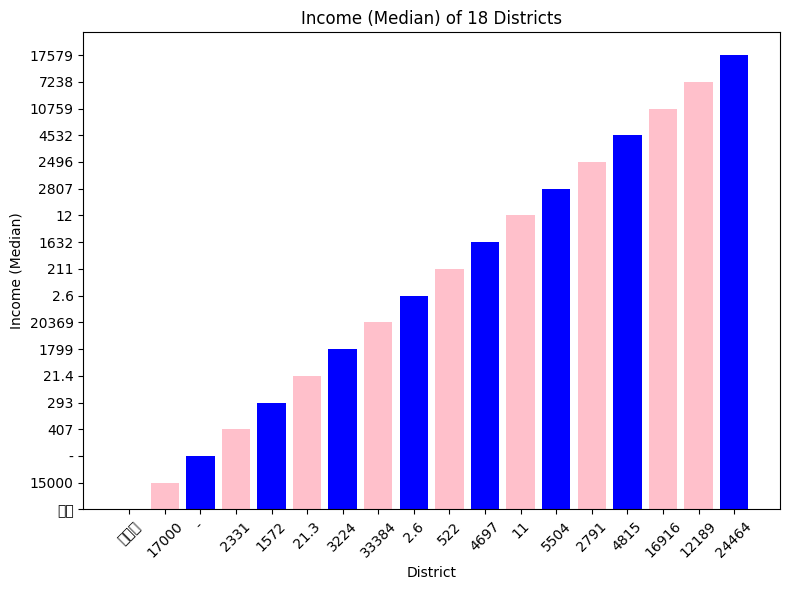

In [6]:
import matplotlib.pyplot as plt
df_filtered = df_factor_selected.iloc[[0, 1]]


plt.figure(figsize=(8, 6))
plt.bar(df_filtered.iloc[0], df_filtered.iloc[1], color=['blue', 'pink'])
plt.xlabel('District')
plt.ylabel('Income (Median)')
plt.title('Income (Median) of 18 Districts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
df_mtr_selected = df_mtr[['Price', 'ON_DISTRICT', 'ON_LINE', 'OFF_LINE', 'DISTANCE', 'COST_INDEX']]
df_mtr_selected.head()

,Price,ON_DISTRICT,ON_LINE,OFF_LINE,DISTANCE,COST_INDEX
0,4.9,中西區,ISL,ISL,803.350860,0.054901
1,4.9,中西區,ISL,ISL,757.782053,0.051787
2,4.9,中西區,ISL,ISL,1584.469234,0.108284
3,5.9,中西區,ISL,ISL,2275.616627,0.187255
4,5.9,中西區,ISL,ISL,2995.483327,0.246491


In [8]:
# 表合并
df_mtr_final = pd.merge(df_mtr_selected, df_factor_selected, left_on='ON_DISTRICT', right_on='區議會分區（中文名稱)', how='inner')
df_mtr_final

,Price,ON_DISTRICT,ON_LINE,OFF_LINE,DISTANCE,COST_INDEX,區議會分區（中文名稱),按性別劃分的每月主要職業收入（港元）中位數（不包括無酬家庭從業員）.2,按房屋類型劃分的有人居住的屋宇單位數目.1,按房屋類型劃分的家庭住戶數目.1,...,按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2,按房屋類型劃分的人口.3,區議會分區,按行業(9)劃分的工作人口.3,按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目,按行業(9)劃分的工作人口.5,按工作地點劃分的工作人口.2,按每月主要職業收入（港元）劃分的工作人口（不包括外籍家庭傭工及無酬家庭從業員）.4,按每月主要職業收入（港元）劃分的工作人口（不包括無酬家庭從業員）.4,按住戶人數劃分的家庭住戶數目
0,4.9,中西區,ISL,ISL,803.350860,0.054901,中西區,17000,-,-,...,522,4697,11,5504,2791,4815,16916,12189,12189,24464
1,4.9,中西區,ISL,ISL,757.782053,0.051787,中西區,17000,-,-,...,522,4697,11,5504,2791,4815,16916,12189,12189,24464
2,4.9,中西區,ISL,ISL,1584.469234,0.108284,中西區,17000,-,-,...,522,4697,11,5504,2791,4815,16916,12189,12189,24464
3,5.9,中西區,ISL,ISL,2275.616627,0.187255,中西區,17000,-,-,...,522,4697,11,5504,2791,4815,16916,12189,12189,24464
4,5.9,中西區,ISL,ISL,2995.483327,0.246491,中西區,17000,-,-,...,522,4697,11,5504,2791,4815,16916,12189,12189,24464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,6.5,元朗,TML,TML,6221.448379,1.017918,元朗,15000,28476,28476,...,4773,3477,34,34750,37207,9248,56494,30049,30049,43382
510,5.4,元朗,TML,TML,3152.614425,0.428522,元朗,15000,28476,28476,...,4773,3477,34,34750,37207,9248,56494,30049,30049,43382
511,5.3,元朗,TML,TML,2127.790837,0.283866,元朗,15000,28476,28476,...,4773,3477,34,34750,37207,9248,56494,30049,30049,43382
512,5.3,屯門,TML,TML,1951.766883,2.650000,屯門,15000,40903,40840,...,4330,7482,33,30729,51839,7572,41987,24847,24847,37399


In [9]:
df_mtr_final = pd.get_dummies(df_mtr_final, columns=['ON_LINE', 'OFF_LINE'])


df_mtr_final.head()

,Price,ON_DISTRICT,DISTANCE,COST_INDEX,區議會分區（中文名稱),按性別劃分的每月主要職業收入（港元）中位數（不包括無酬家庭從業員）.2,按房屋類型劃分的有人居住的屋宇單位數目.1,按房屋類型劃分的家庭住戶數目.1,按房屋類型劃分的人口.1,按房屋類型劃分的有人居住的屋宇單位數目.3,...,ON_LINE_TWL,OFF_LINE_DRL,OFF_LINE_EAL,OFF_LINE_ISL,OFF_LINE_KTL,OFF_LINE_SIL,OFF_LINE_TCL,OFF_LINE_TKL,OFF_LINE_TML,OFF_LINE_TWL
0,4.9,中西區,803.350860,0.054901,中西區,17000,-,-,-,2331,...,False,False,False,True,False,False,False,False,False,False
1,4.9,中西區,757.782053,0.051787,中西區,17000,-,-,-,2331,...,False,False,False,True,False,False,False,False,False,False
2,4.9,中西區,1584.469234,0.108284,中西區,17000,-,-,-,2331,...,False,False,False,True,False,False,False,False,False,False
3,5.9,中西區,2275.616627,0.187255,中西區,17000,-,-,-,2331,...,False,False,False,True,False,False,False,False,False,False
4,5.9,中西區,2995.483327,0.246491,中西區,17000,-,-,-,2331,...,False,False,False,True,False,False,False,False,False,False


In [10]:
columns_to_convert = [
    'ON_LINE_TWL', 
    'OFF_LINE_DRL', 
    'OFF_LINE_EAL', 
    'OFF_LINE_ISL', 
    'OFF_LINE_KTL', 
    'OFF_LINE_SIL', 
    'OFF_LINE_TCL', 
    'OFF_LINE_TKL', 
    'OFF_LINE_TML', 
    'OFF_LINE_TWL'
]

# 将指定的列转换为整数类型
df_mtr_final[columns_to_convert] = df_mtr_final[columns_to_convert].astype(int)
df_mtr_final = df_mtr_final.drop(df_mtr_final.columns[[6, 7, 8]], axis=1)
df_mtr_final.drop(columns=['區議會分區（中文名稱)'], inplace=True)
df_mtr_final.drop(columns=['ON_DISTRICT'], inplace=True)
df_mtr_final = df_mtr_final.drop(df_mtr_final.columns[[19, 20, 21, 22, 23, 24, 25]], axis=1)

df_mtr_final.head()


,Price,DISTANCE,COST_INDEX,按性別劃分的每月主要職業收入（港元）中位數（不包括無酬家庭從業員）.2,按房屋類型劃分的有人居住的屋宇單位數目.3,按房屋類型劃分的家庭住戶數目.3,家庭住戶每月按揭供款及借貸還款與收入比率中位數,按上課地點劃分的於香港院校就讀全日制課程的人口.2,按廳房數目﹝不包括廚房及廁所﹞劃分的家庭住戶數目.2,家庭住戶平均人數,...,ON_LINE_TWL,OFF_LINE_DRL,OFF_LINE_EAL,OFF_LINE_ISL,OFF_LINE_KTL,OFF_LINE_SIL,OFF_LINE_TCL,OFF_LINE_TKL,OFF_LINE_TML,OFF_LINE_TWL
0,4.9,803.350860,0.054901,17000,2331,1572,21.3,3224,33384,2.6,...,0,0,0,1,0,0,0,0,0,0
1,4.9,757.782053,0.051787,17000,2331,1572,21.3,3224,33384,2.6,...,0,0,0,1,0,0,0,0,0,0
2,4.9,1584.469234,0.108284,17000,2331,1572,21.3,3224,33384,2.6,...,0,0,0,1,0,0,0,0,0,0
3,5.9,2275.616627,0.187255,17000,2331,1572,21.3,3224,33384,2.6,...,0,0,0,1,0,0,0,0,0,0
4,5.9,2995.483327,0.246491,17000,2331,1572,21.3,3224,33384,2.6,...,0,0,0,1,0,0,0,0,0,0


In [11]:
import os
output_directory = '../Data/MTR'  
output_file = os.path.join(output_directory, 'processed_mtr_data.xlsx')
df_mtr_final.to_excel(output_file, index=False)
